# EDA of Disaster Images
## Milestone 2


### Data Sampling and Collection


### Data Cleaning

### Exploratory Data Analysis


### Figures



In [1]:
# Load the dataset -- given by the eda starter code
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from load import run

disaster_list = ["hurricane-matthew", "midwest-flooding", "socal-fire"]
data = run(disaster_list)

Loading train images and labels for hurricane-matthew dataset...
Loading train images and labels for midwest-flooding dataset...
Loading train images and labels for socal-fire dataset...


### Number Of Images Per Disaster

In [2]:
images_num = pd.DataFrame()
images_num["Disaster Dataset"] = disaster_list
images_num["Number of Images"] = [len(data[d]["images"]) for d in disaster_list]

display(images_num)


,Disaster Dataset,Number of Images
0,hurricane-matthew,200
1,midwest-flooding,200
2,socal-fire,200


### Image Sizes

In [3]:
sizes = []

for d in disaster_list:
    disaster_size = []
    for image in data[d]["images"]:

        green = image[:,:, 1]  #get one channel only
        mask = green > 0  #where there is no black pixels
        
        rows = np.any(mask, axis=1) #create tuple array of mask
        cols = np.any(mask, axis=0)

        top, bottom = np.where(rows)[0][[0, -1]] #apply tuple to image where first and last are T
        left, right = np.where(cols)[0][[0, -1]]

        cropped = green[top:bottom + 1, left:right + 1]  #reconstruct image as cropped
        disaster_size.append(cropped.size)

    sizes.append(disaster_size)

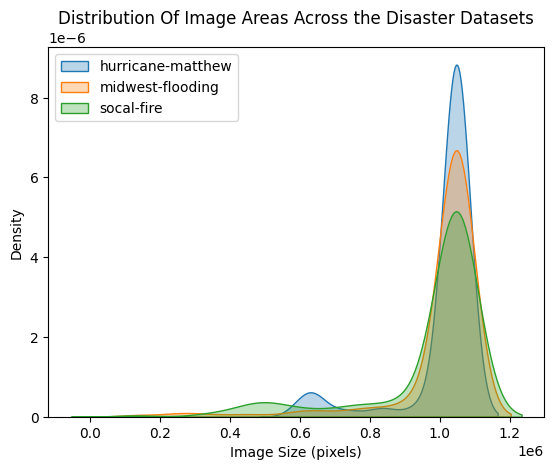

In [4]:
for i in range(3):
    sns.kdeplot(sizes[i], label=disaster_list[i], fill=True, alpha=0.3, )

plt.title("Distribution Of Image Areas Across the Disaster Datasets")
plt.xlabel("Image Size (pixels)")
plt.legend()
plt.show()


### Damage Labels

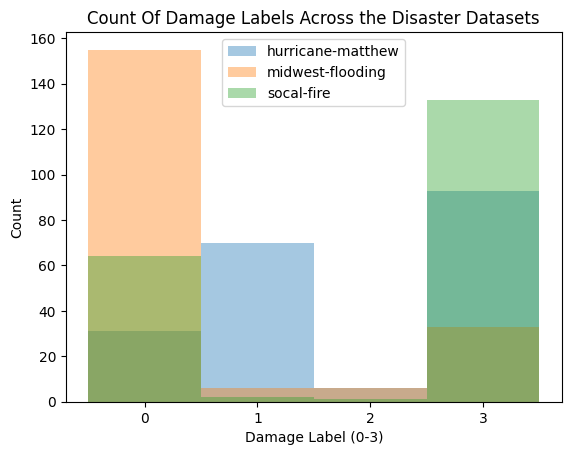

In [62]:
bins = [i - 0.5 for i in range(5)]

for d in disaster_list:
    plt.hist(data[d]["labels"], label = d, fill=True, alpha=0.4 , align='mid', bins = bins)

plt.title("Count Of Damage Labels Across the Disaster Datasets")
plt.xlabel("Damage Label (0-3)")
plt.ylabel("Count")
plt.xticks(range(4))
plt.legend()
plt.show()


### Color Analysis

In [ ]:
from sklearn.cluster import KMeans